In [1]:
# ===============================================
# AI-Powered Customer Segmentation
# Using PCA + K-Means Clustering
# Author: Priyanshi Sharma
# ===============================================

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully ✅")

Matplotlib is building the font cache; this may take a moment.


Libraries Imported Successfully ✅


In [2]:
# ===============================================
# Load the Dataset
# ===============================================

df = pd.read_csv("../dataset/Mall_Customers.csv")

# Display first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Shape of Dataset

df.shape

(200, 5)

In [4]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
# Statistical Summary of Dataset

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
# Check Missing Values

df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
# Check Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [8]:
# Display Column Names

df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [9]:
# Check Data Types

df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

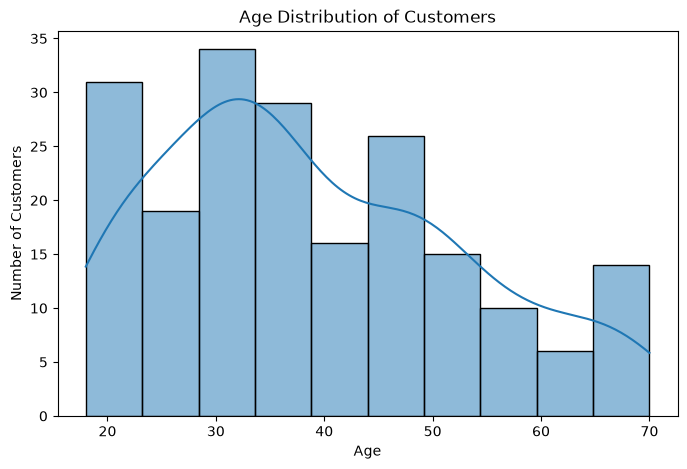

In [10]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=10, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

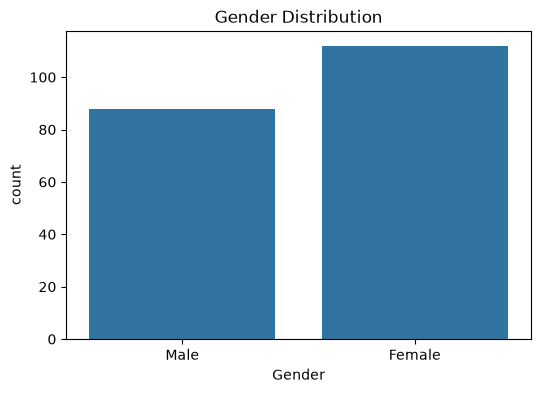

In [11]:
# Gender Distribution

plt.figure(figsize=(6,4))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()

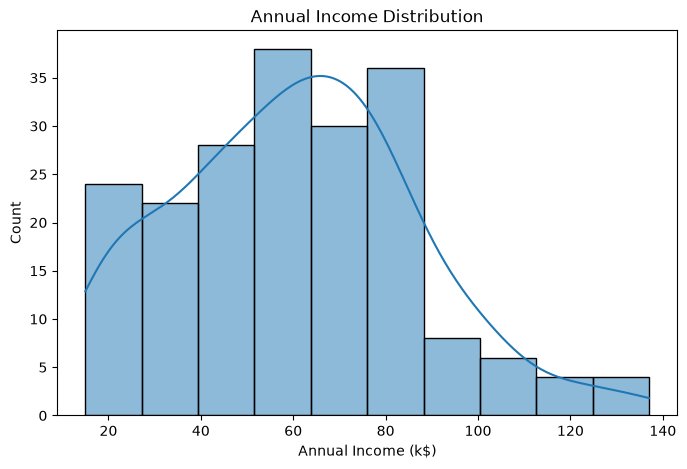

In [12]:
# Annual Income Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=10, kde=True)

plt.title("Annual Income Distribution")

plt.show()

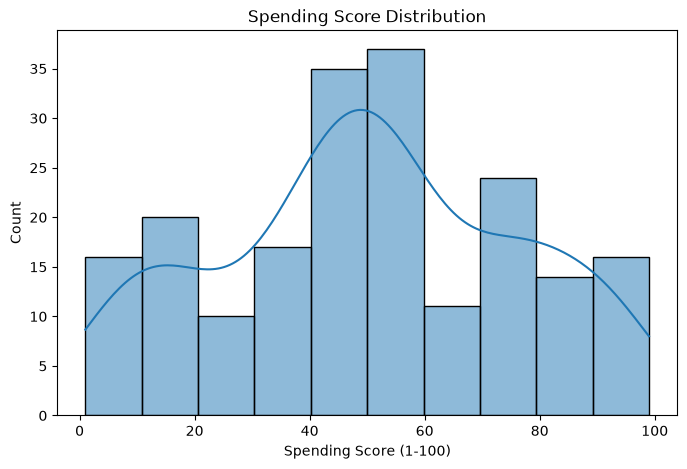

In [13]:
# Spending Score Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score (1-100)"], bins=10, kde=True)

plt.title("Spending Score Distribution")

plt.show()

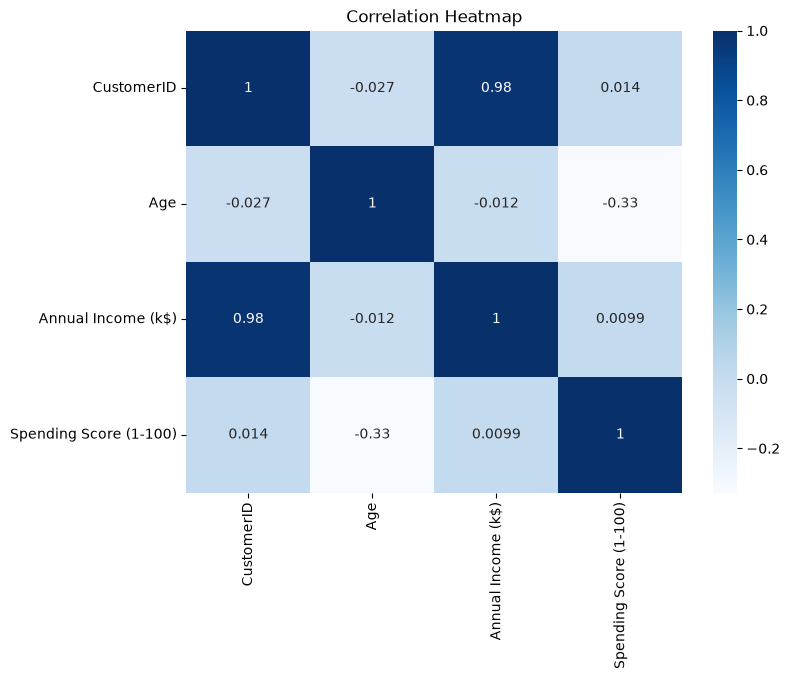

In [14]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

In [15]:
# ==========================================
# Feature Selection
# ==========================================

X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [16]:
# ==========================================
# Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [17]:
# ==========================================
# PCA (Dimensionality Reduction)
# ==========================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca[:5])

[[-0.61572002 -1.76348088]
 [-1.66579271 -1.82074695]
 [ 0.33786191 -1.67479894]
 [-1.45657325 -1.77242992]
 [-0.03846521 -1.66274012]]


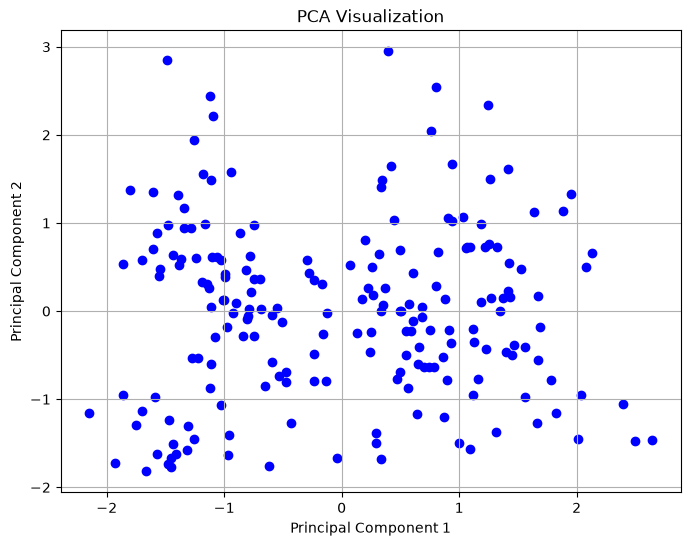

In [18]:
# ==========================================
# PCA Visualization
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], color='blue')

plt.title("PCA Visualization")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

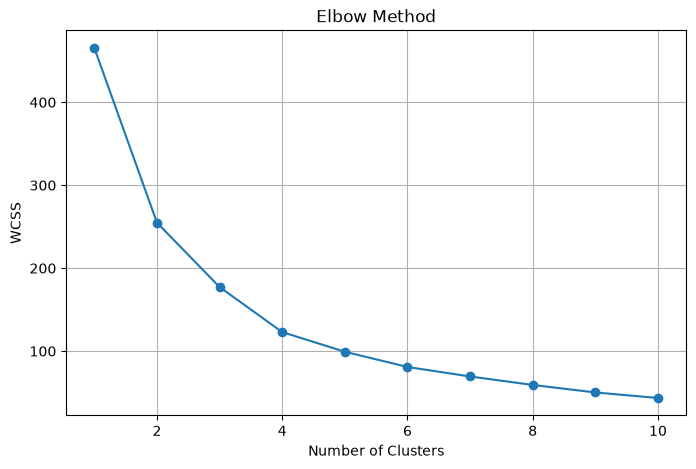

In [19]:
# ==========================================
# Elbow Method
# ==========================================

from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [29]:
# ==========================================
# Apply K-Means
# ==========================================

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = clusters = kmeans.fit_predict(X_scaled)

clusters

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1,
       4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1,
       1, 4, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 4, 4,
       4, 1, 3, 1, 1, 1, 4, 4, 4, 4, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

In [21]:
# ==========================================
# Add Cluster Column
# ==========================================

df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,0
3,4,Female,23,16,77,4
4,5,Female,31,17,40,4


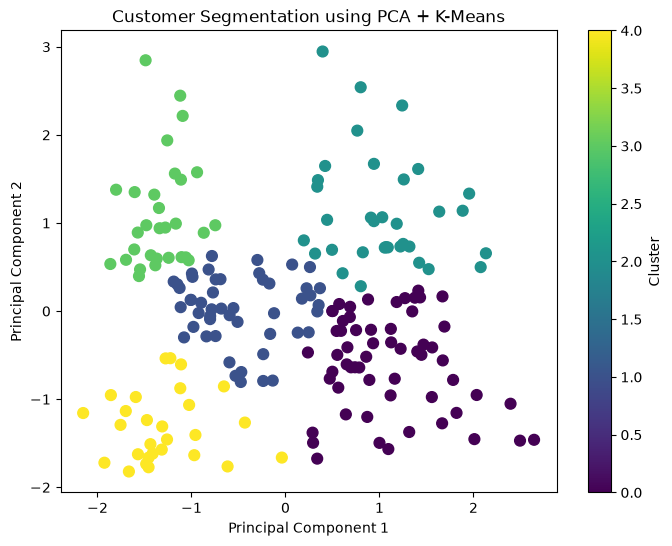

In [22]:
# ==========================================
# Visualize Clusters
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=60
)

plt.title("Customer Segmentation using PCA + K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [23]:
# ==========================================
# Cluster Summary
# ==========================================

df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,53.559322,43.779661,38.508475
1,30.489796,61.551020,52.612245
2,43.264706,88.470588,18.617647
3,31.733333,90.866667,83.266667
4,24.750000,27.821429,73.535714


In [24]:
# ==========================================
# Save Result
# ==========================================

df.to_csv("../dataset/customer_segments.csv", index=False)

print("Customer Segmentation Completed Successfully!")

Customer Segmentation Completed Successfully!


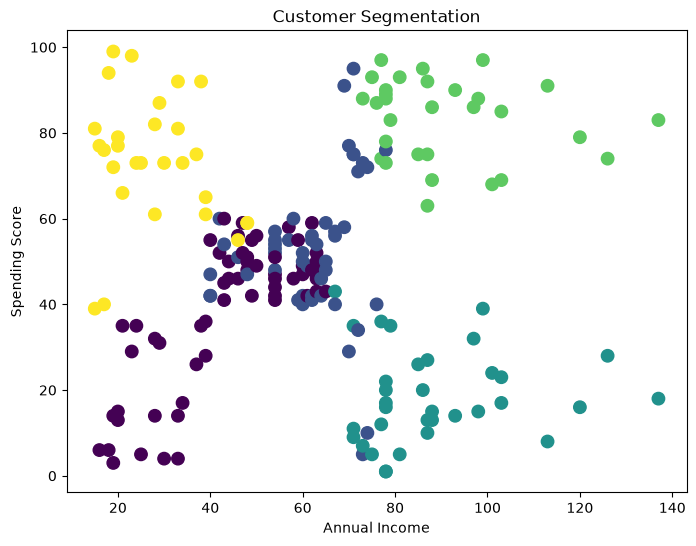

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=80
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.savefig("../static/images/customer_segmentation.png")

plt.show()

In [28]:
import joblib

# Save the scaler
joblib.dump(scaler, "../model/scaler.pkl")

# Save the K-Means model
joblib.dump(kmeans, "../model/kmeans_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [30]:
import joblib

joblib.dump(scaler, "../model/scaler.pkl")
joblib.dump(pca, "../model/pca.pkl")
joblib.dump(kmeans, "../model/kmeans_model.pkl")

print("All Models Saved Successfully!")

All Models Saved Successfully!
